In [ ]:
#Jiayan Wang Homework3

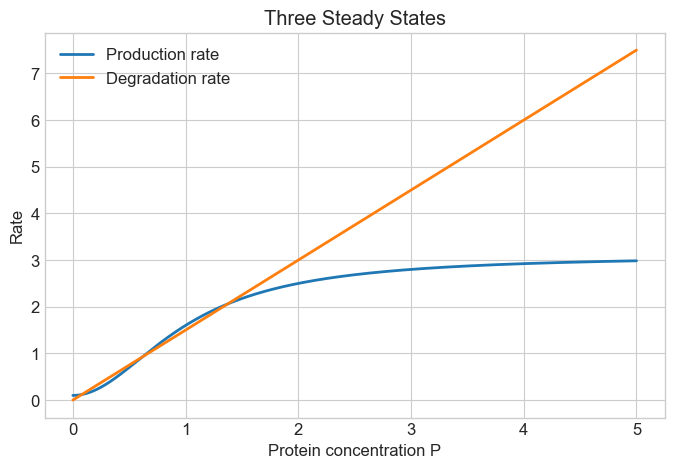

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


def production(P,beta0, beta, K, n):
    """
    Hill self-activation production rate.
    """
    return beta0+beta * P**n / (K**n + P**n)


def model(t, y, beta0,beta, K, n, gamma):
    """
    Positive feedback with degradation:
    dP/dt = production - degradation
    """
    P = y[0]

    synthesis = production(P, beta0,beta, K, n)
    degradation = gamma * P

    dPdt = synthesis - degradation

    return [dPdt]


# Parameters chosen to produce three steady states
beta0 = 0.1
beta = 3.0
K = 1.0
n = 2.0
gamma = 1.5

# Protein concentration range
P = np.linspace(0, 5, 1000)

# Production and degradation rates
production_rate = production(P, beta0,beta, K, n)
degradation_rate = gamma * P

# Plot the two curves
plt.figure(figsize=(8, 5))

plt.plot(
    P,
    production_rate,
    label="Production rate",
    linewidth=2
)

plt.plot(
    P,
    degradation_rate,
    label="Degradation rate",
    linewidth=2
)

plt.xlabel("Protein concentration P")
plt.ylabel("Rate")
plt.title("Three Steady States")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
from scipy.optimize import brentq


def steady_state_equation(P, beta0,beta, K, n, gamma):
    """
    The steady-state equation:
    production rate - degradation rate = 0
    """
    return production(P, beta0,beta, K, n) - gamma * P


# Find possible roots numerically
P_values = np.linspace(0, 5, 1000)
roots = []

for i in range(len(P_values) - 1):
    left = P_values[i]
    right = P_values[i + 1]

    f_left = steady_state_equation(left,beta0, beta, K, n, gamma)
    f_right = steady_state_equation(right,beta0, beta, K, n, gamma)

    if f_left * f_right < 0:
        root = brentq(
            steady_state_equation,
            left,
            right,
            args=(beta0,beta, K, n, gamma)
        )
        roots.append(root)

# Add the zero steady state if necessary
#roots = [0.0] + roots

print("Equilibrium solutions:")

labels = [
    "Stable steady state",
    "Unstable equilibrium",
    "Stable steady state",
]

for root, label in zip(roots, labels):
    print(f"P = {root:.3f} ({label})")

Equilibrium solutions:
P = 0.079 (Stable steady state)
P = 0.613 (Unstable equilibrium)
P = 1.374 (Stable steady state)


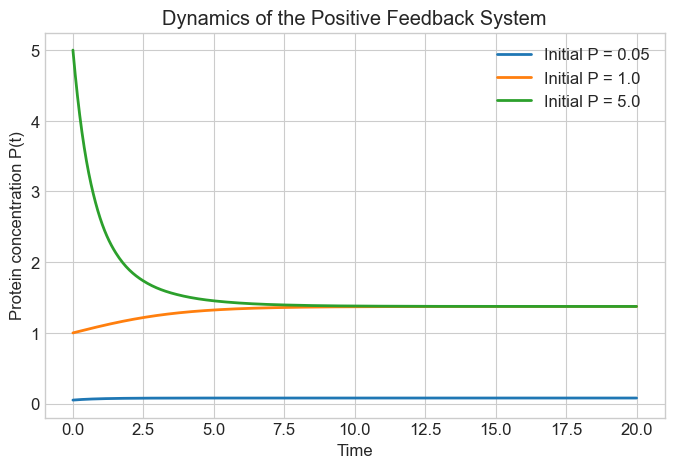

In [20]:
# Time range
t = np.linspace(0, 20, 500)

# Different initial concentrations
initial_conditions = [0.05, 1.0, 5.0]

plt.figure(figsize=(8, 5))

for P0 in initial_conditions:
    solution = solve_ivp(
        model,
        [t[0], t[-1]],
        [P0],
        t_eval=t,
        args=(beta0,beta, K, n, gamma)
    )

    plt.plot(
        solution.t,
        solution.y[0],
        linewidth=2,
        label=f"Initial P = {P0}"
    )

plt.xlabel("Time")
plt.ylabel("Protein concentration P(t)")
plt.title("Dynamics of the Positive Feedback System")
plt.legend()
plt.grid(True)
plt.show()